In [2]:
import json
import sqlite3
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

In [3]:
def process_sqlite_report_kernel_only(filePath):
    con = sqlite3.connect(filePath)
    con.row_factory = sqlite3.Row 
    cur = con.cursor()
    query = """
    SELECT
        'kernel' AS activity_type,
        names.value AS name,
        k.start,
        k.end,
        k.end - k.start AS duration,
        k.registersPerThread,
        k.gridX, k.gridY, k.gridZ,
        k.blockX, k.blockY, k.blockZ,
        k.staticSharedMemory, k.dynamicSharedMemory,
        k.localMemoryPerThread, k.localMemoryTotal,
        k.sharedMemoryLimitConfig,
        k.streamId,
        k.deviceId,
        NULL AS bytes,
        NULL AS copyKind,
        NULL as srcKind,
        NULL as dstKind,
        NULL AS memKind          -- new column for memset
    FROM CUPTI_ACTIVITY_KIND_KERNEL AS k
    JOIN StringIds AS names ON k.demangledName = names.id
    
    ORDER BY start;
    """

    cur.execute(query)
    rows = [dict(row) for row in cur.fetchall()]
    return rows

In [4]:
# 50kX50k match matrix for different scenarios (4 warmup runs)
data_matrix = process_sqlite_report_kernel_only("build/Linux-x86_64/pool_matching_joint_matrix_fp16.sqlite")

# fp16 is just to show that it does not matter much
data_normal_fp16 = process_sqlite_report_kernel_only("build_normal/Linux-x86_64/pool_matching_normal_fp16.sqlite")
data_normal_fp32 = process_sqlite_report_kernel_only("build_normal_fp32/Linux-x86_64/pool_matching_normal_fp32.sqlite")

data_matrix_zero_tail = process_sqlite_report_kernel_only("build/Linux-x86_64/fp32_norm_fp16_matrix_match.sqlite") # It's csv: mixed_precision_joint_matrix_.csv

# Better occupancy for normal matching
normal_big_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/match_normal_big_wg_new.sqlite") # csv: match_normal_big_wg.csv
# Better occupancy for matrix matching
# Need to run those for 50kx50k
# OR maybe I don't need these (as they are slower than data_matrix anyways)

# CUDA normal versions
cuda_normal = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda-fp32-match.sqlite")
cuda_normal_big_wg = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda_normal_big_wg_new.sqlite")


In [5]:
len(data_matrix_zero_tail)

7512

In [6]:
def tensor_replace_names(data):
    pattern = r'\blambda\b'
    for row in data:
        match = re.search(pattern, row["name"])
        if match: 
            row["name"] = "remainder_normal_matching"
        if row["name"] == "Typeinfo name for popsift::Compute_distance_matrix_pre_norm":
            row["name"] = "matrix_matching"
        if row["name"] in ("Typeinfo name for popsift::Compute_squared_norm", "Typeinfo name for popsift::Compute_squared_norm_fp16_transform"):
            row["name"] = "compute_squared_norm"        

In [7]:
tensor_replace_names(data_matrix)
tensor_replace_names(data_matrix_zero_tail)

In [8]:
def tensor_match_time(data, warmup=4):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            start = row["start"]
            current_frame = True
        else: 
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > warmup:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > warmup:
                        times.append(row["end"] - start)
    return times

In [9]:
def tensor_only_match_time(data):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            # start = row["start"]
            current_frame = True
        else: 
            if current_frame:
                start = row["start"]
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > 4:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > 4:
                        times.append(row["end"] - start)
    return times

In [10]:
def normal_match_time(data, warmup=4):
    times: list[int] = []
    for row in data:
        times.append(row["duration"])
    return times[warmup:]

In [11]:
# TIMES 50Kx50K

# Tensor times:
times_matrix = tensor_match_time(data_matrix)
times_matrix_zero_tail = tensor_match_time(data_matrix_zero_tail)

# Only match tensor match times (not including norm computation):
times_matrix_only_match = tensor_only_match_time(data_matrix)
times_matrix_zero_tail_only_match = tensor_only_match_time(data_matrix_zero_tail)


# Normal times:
times_normal_fp16 = normal_match_time(data_normal_fp16)
times_normal_fp32 = normal_match_time(data_normal_fp32)
times_normal_big_wg = normal_match_time(normal_big_wg)

# CUDA times:
times_cuda_normal = normal_match_time(cuda_normal)
times_cuda_normal_big_wg = normal_match_time(cuda_normal_big_wg)

In [12]:
# Just used for the left and right dimensions which is the same for all above (50Kx50K)
normal_meta = pd.read_csv("build_normal_fp32/Linux-x86_64/matching_normal_fp32_metadata.csv")

In [13]:
def listify(data):
    l = data["l_desc_size"].tolist()[4:]
    r = data["r_desc_size"].tolist()[4:]
    return l, r

In [14]:
left_desc_len, right_desc_len = listify(normal_meta)

In [15]:
def diff(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] - b[i])
    return diff_list
    
def diff_percent(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(100 * (a[i] - b[i]) / b[i])
    return diff_list

def diff_mult(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] / b[i])
    return diff_list

def diff_log2(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append(np.log2(a[i] / b[i]))
    return diff_list

def distance_around_zero(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append((a[i] - b[i])/min(a[i], b[i]))
    return diff_list

In [16]:
matrix_v_1_wg_normal_mult = diff_mult(times_normal_fp32, times_matrix)
sycl_v_cuda_small_wg_mult = diff_mult(times_normal_fp32, times_cuda_normal)

matrix_zero_v_big_wg_sycl_mult = diff_mult(times_normal_big_wg, times_matrix_zero_tail)
matrix_v_matrix_zero_linear = distance_around_zero(times_matrix, times_matrix_zero_tail)
matrix_v_matrix_zero_match_only_linear = distance_around_zero(times_matrix_only_match, times_matrix_zero_tail_only_match)

In [17]:
cuda_v_sycl_small_wg_linear = distance_around_zero(times_cuda_normal, times_normal_fp32)
cuda_v_sycl_big_wg_linear = distance_around_zero(times_cuda_normal_big_wg, times_normal_big_wg)

In [18]:
times_matrix[:5]

[519009, 973057, 1448545, 1914369, 2389857]

In [19]:
times_matrix_zero_tail[:5]

[165217, 303746, 442594, 580580, 731012]

In [20]:
times_cuda_normal_big_wg[-5:]

[611788276, 629737590, 640778546, 655569336, 667228022]

In [21]:
times_normal_big_wg[-5:]

[587466536, 601483637, 618604051, 638665086, 650399133]

In [22]:
def scatter_3d_plot(x, y, z, xlabel, ylabel, zlabel, title, error_bar_label, rotate=False):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    if rotate:
        scatter = ax.scatter(y, x, z, c=z, cmap='magma', edgecolor='k')
        ax.set_xlabel(ylabel)
        ax.set_ylabel(xlabel)
    else:
        scatter = ax.scatter(x, y, z, c=z, cmap='magma', edgecolor='k')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    ax.set_zlabel(zlabel)
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label=error_bar_label)
    plt.tight_layout()

    plt.show()

In [23]:
def heatmap_2d_plot_around_zero(x, y, z, xlabel, ylabel, title, error_bar_label, cmap='seismic'):
    # plt.figure(figsize=(12, 8))

    vmin = np.min(z)
    vmax = np.max(z)
    abs_max = max(abs(vmin), abs(vmax))
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    plt.scatter(
        left_desc_len, right_desc_len,
        c=z,
        cmap=cmap,
        norm=norm
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(label=error_bar_label)
    # plt.tight_layout()
    plt.show()

In [24]:
def heatmap_2d_plot(x, y, z, xlabel, ylabel, title, error_bar_label, cmap='magma'):
    plt.scatter(
        left_desc_len, right_desc_len,
        c=z,
        cmap=cmap
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(label=error_bar_label)
    plt.show()

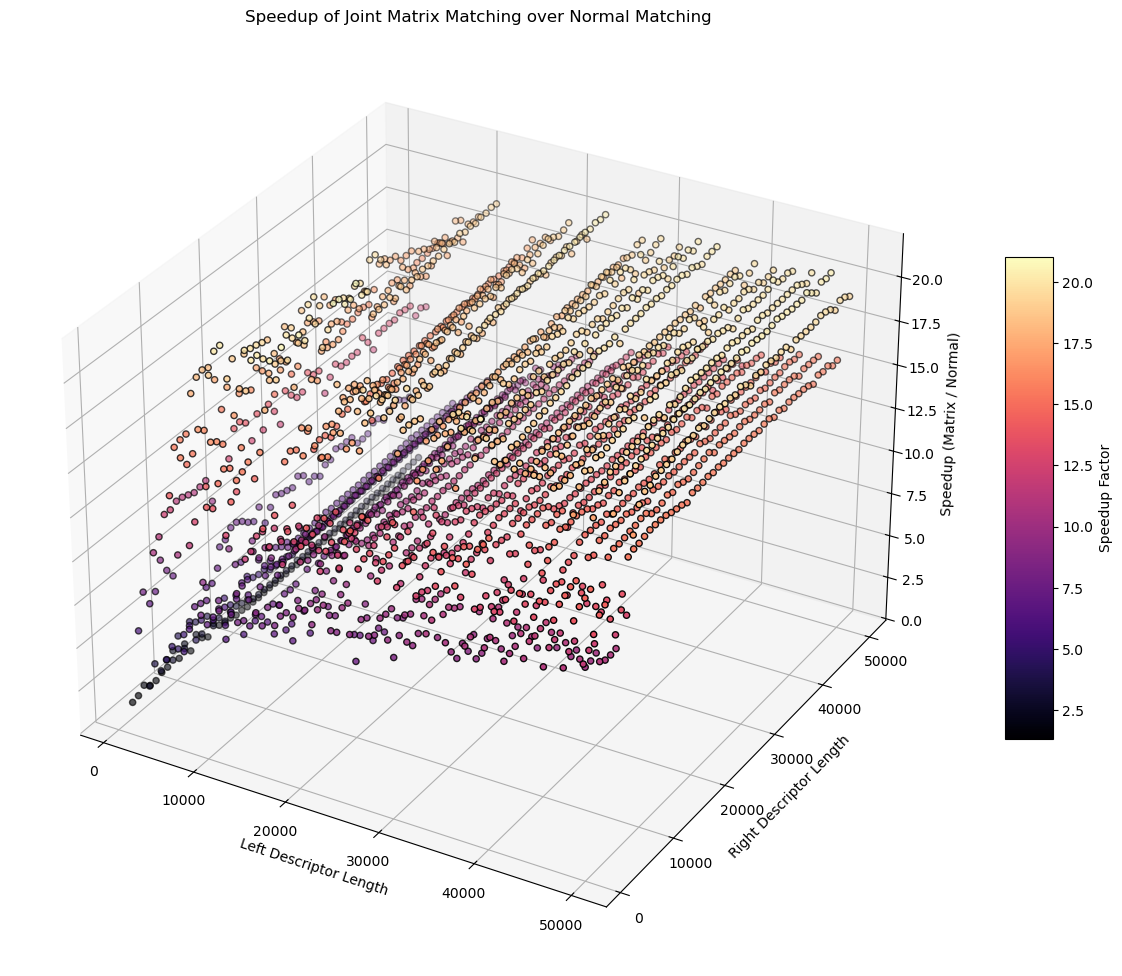

In [25]:
scatter_3d_plot(left_desc_len, right_desc_len, matrix_v_1_wg_normal_mult,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                zlabel='Speedup (Matrix / Normal)',
                title='Speedup of Joint Matrix Matching over Normal Matching',
                error_bar_label='Speedup Factor', 
                rotate=False)

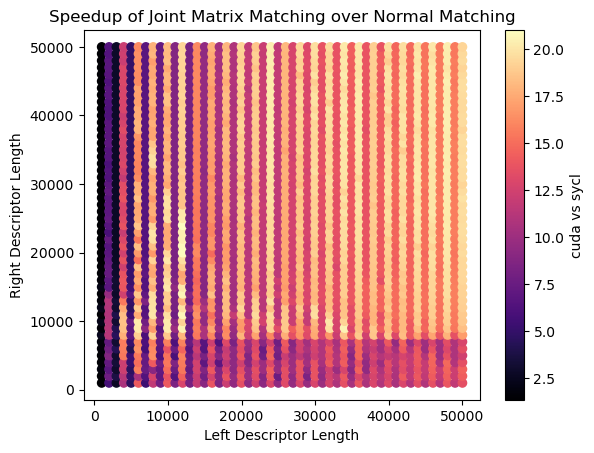

In [26]:
heatmap_2d_plot(left_desc_len, right_desc_len, matrix_v_1_wg_normal_mult,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Speedup of Joint Matrix Matching over Normal Matching',
                error_bar_label='cuda vs sycl')

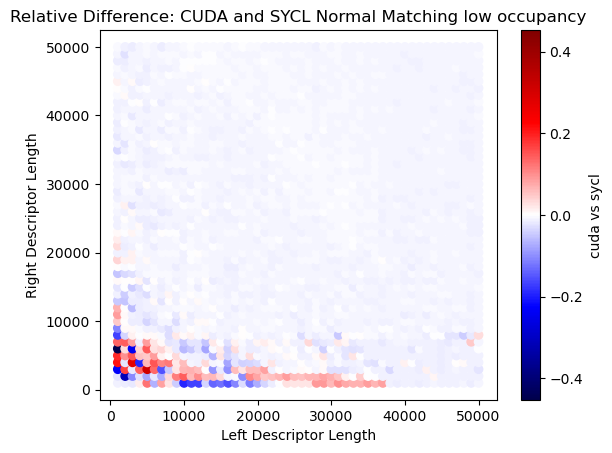

In [27]:
heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, cuda_v_sycl_small_wg_linear,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Relative Difference: CUDA and SYCL Normal Matching low occupancy',
                error_bar_label='cuda vs sycl')


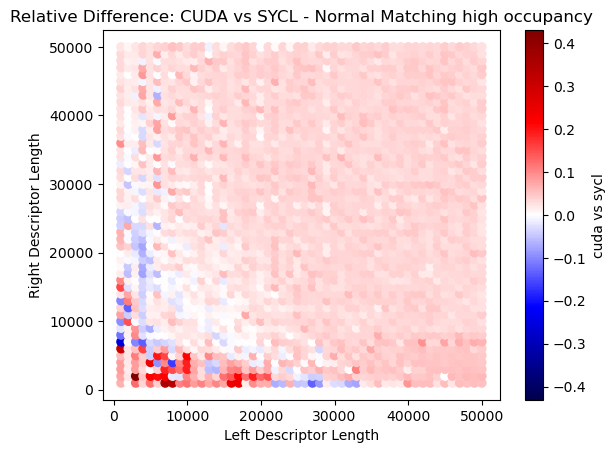

In [28]:
heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, cuda_v_sycl_big_wg_linear,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Relative Difference: CUDA vs SYCL - Normal Matching high occupancy',
                error_bar_label='cuda vs sycl')

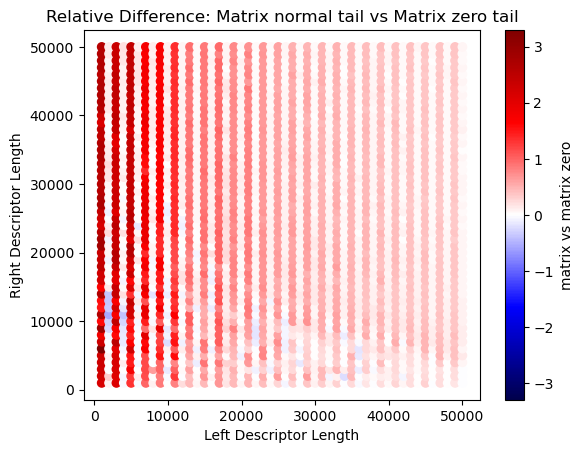

In [29]:
heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, matrix_v_matrix_zero_linear,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Relative Difference: Matrix normal tail vs Matrix zero tail',
                error_bar_label='matrix vs matrix zero')

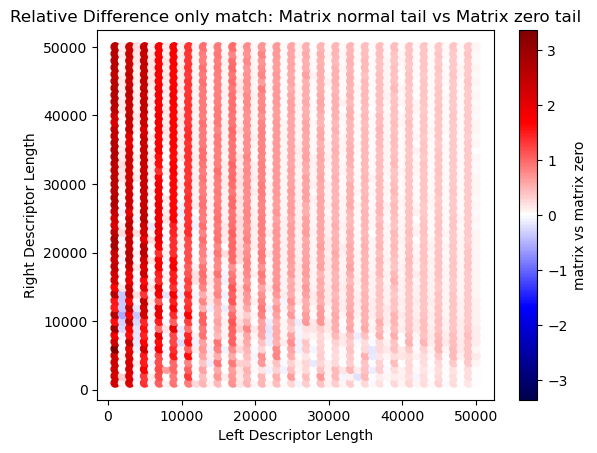

In [30]:

heatmap_2d_plot_around_zero(left_desc_len, right_desc_len, matrix_v_matrix_zero_match_only_linear,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Relative Difference only match: Matrix normal tail vs Matrix zero tail',
                error_bar_label='matrix vs matrix zero')

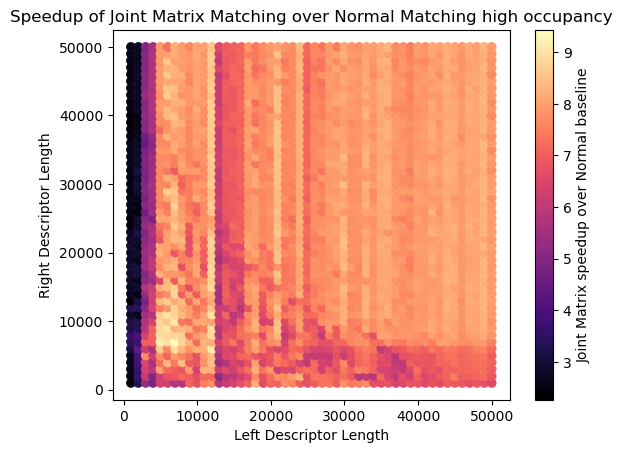

In [31]:
# Good matrix vs good occupancy normal sycl
heatmap_2d_plot(left_desc_len, right_desc_len, matrix_zero_v_big_wg_sycl_mult,
                xlabel='Left Descriptor Length',
                ylabel='Right Descriptor Length',
                title='Speedup of Joint Matrix Matching over Normal Matching high occupancy',
                error_bar_label='Joint Matrix speedup over Normal baseline')

In [32]:
# 1k - 80k lr same with 20 repetations and 10 warmup runs

# SYCL tensor
matrix_lr_same_zero = process_sqlite_report_kernel_only("build/Linux-x86_64/match_matrix_zero_tail_lr_same.sqlite")
matrix_lr_same_1_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/tensor_lr_same_1_sg_per_wg.sqlite")
matrix_lr_same_2_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/tensor_lr_same_2_sg_per_wg.sqlite")
matrix_lr_same_3_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/tensor_lr_same_3_sg_per_wg.sqlite")

 
# SYCL normal
normal_lr_same = process_sqlite_report_kernel_only("build/Linux-x86_64/match_normal_lr_same.sqlite")
normal_lr_same_big_wg = process_sqlite_report_kernel_only("build/Linux-x86_64/match_normal_lr_same_big_wg_new.sqlite")

# CUDA normal
cuda_normal_lr_same = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda_normal_lr_same.sqlite")
cuda_normal_lr_same_big_wg = process_sqlite_report_kernel_only("../popsift/build/Linux-x86_64/cuda_normal_lr_same_big_wg_new.sqlite")



In [33]:
tensor_replace_names(matrix_lr_same_zero)
tensor_replace_names(matrix_lr_same_1_wg)
tensor_replace_names(matrix_lr_same_2_wg)
tensor_replace_names(matrix_lr_same_3_wg)

In [34]:
# Sycl tensor times:
times_matrix_lr_same_zero = tensor_match_time(matrix_lr_same_zero, 10)
times_matrix_lr_same_1_wg = tensor_match_time(matrix_lr_same_1_wg, 10)
times_matrix_lr_same_2_wg = tensor_match_time(matrix_lr_same_2_wg, 10)
times_matrix_lr_same_3_wg = tensor_match_time(matrix_lr_same_3_wg, 10)

# SYCL normal
times_normal_lr_same = normal_match_time(normal_lr_same, 10)
times_normal_lr_same_big_wg = normal_match_time(normal_lr_same_big_wg, 10)

# CUDA normal
times_cuda_normal_lr_same = normal_match_time(cuda_normal_lr_same, 10)
times_cuda_normal_lr_same_big_wg = normal_match_time(cuda_normal_lr_same_big_wg, 10)

In [35]:
# Only care about lenght so use the same for all
lr_same_length = pd.read_csv("build/Linux-x86_64/tensor_lr_same_3_sg_per_wg.csv")[10:].reset_index(drop=True)

In [36]:
lr_same_length

,l_desc_size,r_desc_size,matches
0,1000,1000,130
1,2000,2000,228
2,3000,3000,333
3,4000,4000,405
4,5000,5000,542
...,...,...,...
1595,76000,76000,6050
1596,77000,77000,6321
1597,78000,78000,6258
1598,79000,79000,6471


In [37]:
def mean_std_compute(data):
    data_ms = [x / 1000000 for x in data]  # Convert to ms
    mean = []
    std = []
    for i in range(80):
        vals = []
        for j in range(20):
            vals.append(data_ms[i + j*80])

        mean.append(np.mean(vals))
        std.append(np.std(vals))
    return mean, std

In [38]:
mean_matrix_lr_zero, std_matrix_lr_zero = mean_std_compute(times_matrix_lr_same_zero)
mean_matrix_lr_1_wg, std_matrix_lr_1_wg = mean_std_compute(times_matrix_lr_same_1_wg)
mean_matrix_lr_2_wg, std_matrix_lr_2_wg = mean_std_compute(times_matrix_lr_same_2_wg)
mean_matrix_lr_3_wg, std_matrix_lr_3_wg = mean_std_compute(times_matrix_lr_same_3_wg)   

mean_normal_lr_same, std_normal_lr_same = mean_std_compute(times_normal_lr_same)
mean_normal_lr_same_big_wg, std_normal_lr_same_big_wg = mean_std_compute(times_normal_lr_same_big_wg)

mean_cuda_normal_lr_same, std_cuda_normal_lr_same = mean_std_compute(times_cuda_normal_lr_same)
mean_cuda_normal_lr_same_big_wg, std_cuda_normal_lr_same_big_wg = mean_std_compute(times_cuda_normal_lr_same_big_wg)

In [39]:
for i in range(80):
    print(f"{lr_same_length['l_desc_size'][i]}, Matrix: {mean_matrix_lr_zero[i]:.4f} ± {std_matrix_lr_zero[i]:.4f}, Matrix 3 WG: {mean_matrix_lr_3_wg[i]:.4f} ± {std_matrix_lr_3_wg[i]:.4f}, Normal SYCL: {mean_normal_lr_same[i]:.4f} ± {std_normal_lr_same[i]:.4f}, Normal SYCL big WG: {mean_normal_lr_same_big_wg[i]:.4f} ± {std_normal_lr_same_big_wg[i]:.4f}, Normal CUDA: {mean_cuda_normal_lr_same[i]:.4f} ± {std_cuda_normal_lr_same[i]:.4f}, Normal CUDA big WG: {mean_cuda_normal_lr_same_big_wg[i]:.4f} ± {std_cuda_normal_lr_same_big_wg[i]:.4f}")
    

1000, Matrix: 0.1764 ± 0.0034, Matrix 3 WG: 0.1705 ± 0.0023, Normal SYCL: 0.7297 ± 0.0030, Normal SYCL big WG: 0.3903 ± 0.0013, Normal CUDA: 0.7269 ± 0.0330, Normal CUDA big WG: 0.4195 ± 0.0023
2000, Matrix: 0.3211 ± 0.0050, Matrix 3 WG: 0.3053 ± 0.0064, Normal SYCL: 2.8481 ± 0.2533, Normal SYCL big WG: 1.1633 ± 0.0018, Normal CUDA: 2.5693 ± 0.0985, Normal CUDA big WG: 1.1851 ± 0.0030
3000, Matrix: 0.4887 ± 0.0618, Matrix 3 WG: 0.5063 ± 0.0117, Normal SYCL: 4.6078 ± 0.2036, Normal SYCL big WG: 3.0712 ± 0.1179, Normal CUDA: 4.8253 ± 0.2235, Normal CUDA big WG: 3.4670 ± 0.0995
4000, Matrix: 0.7508 ± 0.0812, Matrix 3 WG: 0.7054 ± 0.0775, Normal SYCL: 10.4315 ± 0.5883, Normal SYCL big WG: 4.2238 ± 0.0220, Normal CUDA: 10.2666 ± 0.4732, Normal CUDA big WG: 4.4020 ± 0.0653
5000, Matrix: 1.0317 ± 0.0197, Matrix 3 WG: 1.2684 ± 0.0177, Normal SYCL: 14.6626 ± 0.7178, Normal SYCL big WG: 8.7161 ± 0.2912, Normal CUDA: 14.7296 ± 0.5217, Normal CUDA big WG: 9.7242 ± 0.2357
6000, Matrix: 1.3195 ± 0.0

In [40]:
nvidia_color = "#76b900"
intel_color = "#00C7FD"
intel_color_dark = "#0068B5"

In [41]:
x_scatter = lr_same_length['l_desc_size'].unique()

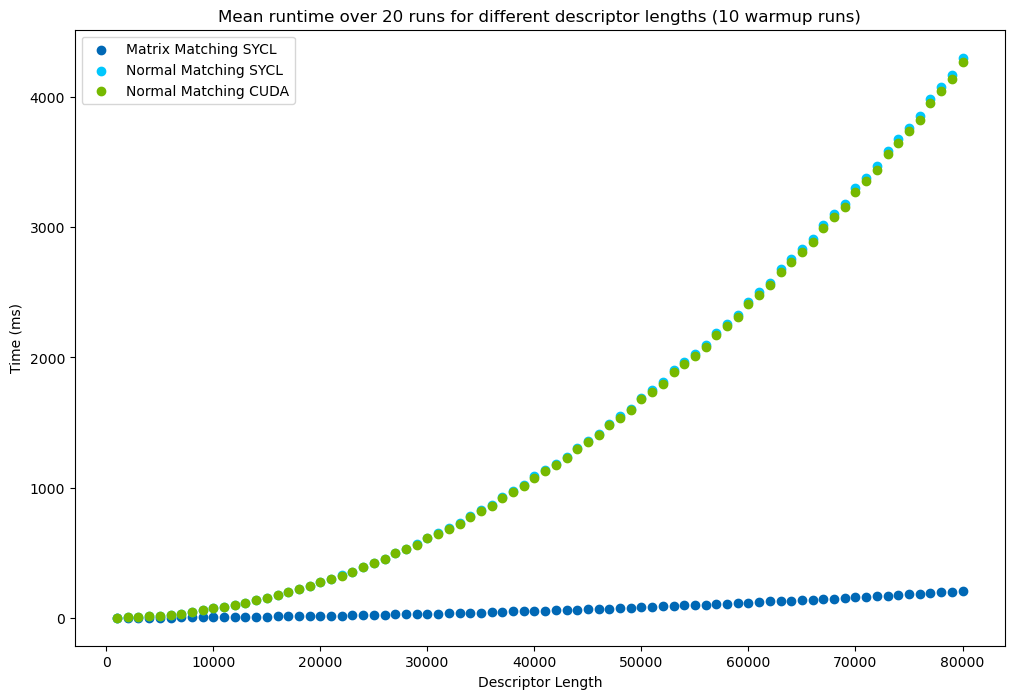

In [42]:
plt.figure(figsize=(12, 8))
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark)
plt.scatter(x_scatter, mean_normal_lr_same, label='Normal Matching SYCL', color=intel_color)
plt.scatter(x_scatter, mean_cuda_normal_lr_same, label='Normal Matching CUDA', color=nvidia_color)

plt.xlabel('Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)') 
plt.legend()
plt.show()

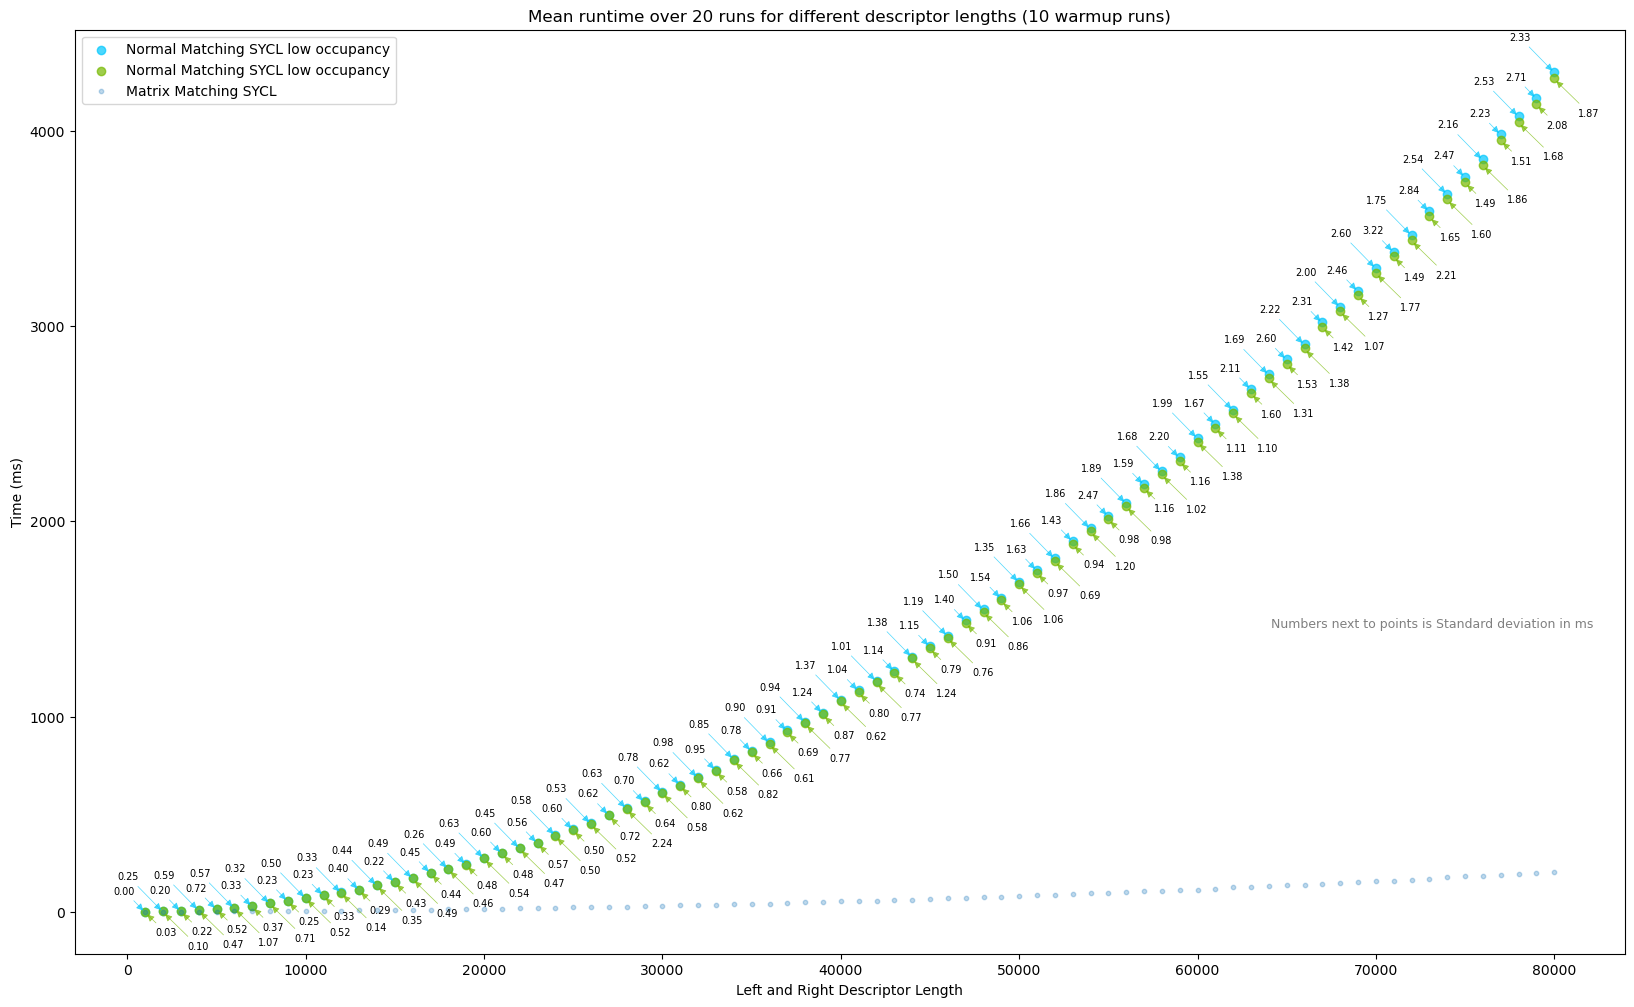

In [43]:
# scatter normal vs normal with std annotated
plt.figure(figsize=(20, 12))
plt.scatter(x_scatter, mean_normal_lr_same, label='Normal Matching SYCL low occupancy', color=intel_color, alpha=0.7)
plt.scatter(x_scatter, mean_cuda_normal_lr_same, label='Normal Matching SYCL low occupancy', color=nvidia_color, alpha=0.7)
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.25, s=10)


offsets = [(15, -15), (25, -25)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]


plt.text(0.98, 0.35,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same, std_cuda_normal_lr_same), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 5), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
    )


offsets_sycl = [(-15, 15), (-25, 25)]
offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same, std_normal_lr_same), offsets_sycl):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 5), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
    )

plt.xlabel('Left and Right Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

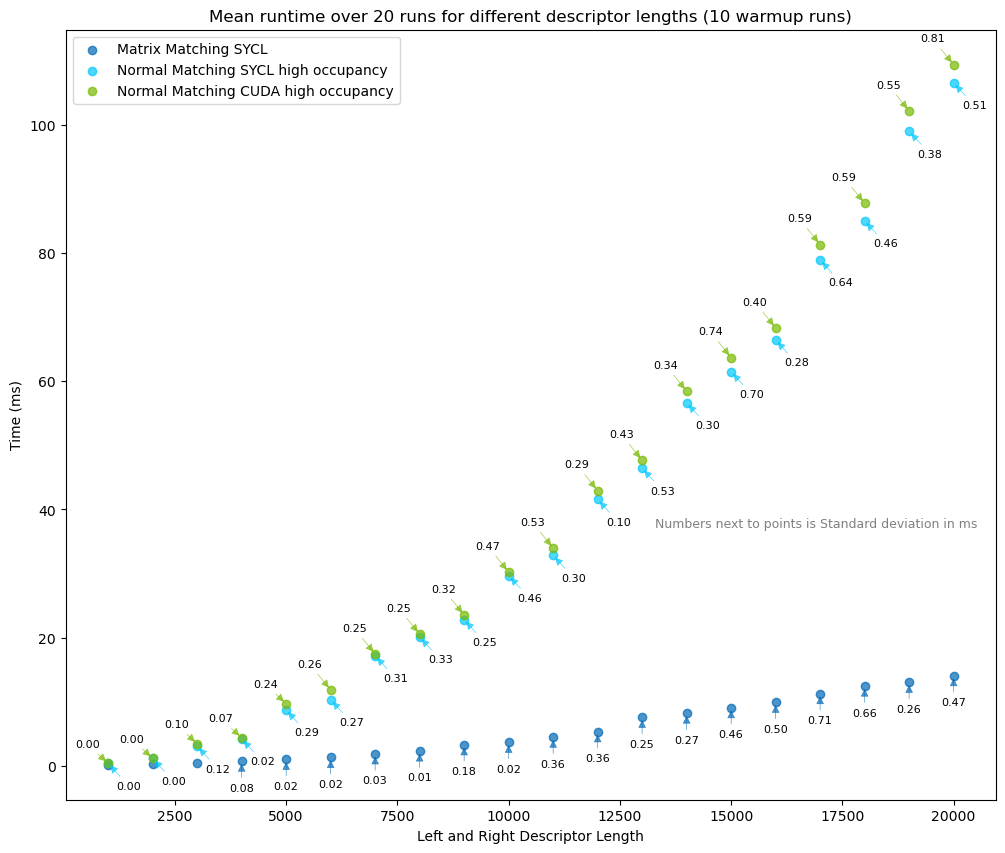

In [44]:
# Only plot first 20 (zoom in)


plt.figure(figsize=(12, 10))
plt.scatter(x_scatter[:20], mean_matrix_lr_zero[:20], label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.7)
plt.scatter(x_scatter[:20], mean_normal_lr_same_big_wg[:20], label='Normal Matching SYCL high occupancy', color=intel_color, alpha=0.7)
plt.scatter(x_scatter[:20], mean_cuda_normal_lr_same_big_wg[:20], label='Normal Matching CUDA high occupancy', color=nvidia_color, alpha=0.7)


plt.text(0.98, 0.35,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')

# offsets = [(0, -15), (0, -25)]
offsets = [(0, -23)]
offsets = (offsets * ((len(x_scatter[:20]) // len(offsets[:20])) + 1))[:len(x_scatter[:20])]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter[:20], mean_matrix_lr_zero[:20], std_matrix_lr_zero[:20]), offsets):
    if xi > 3000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy),
            ha='center', 
            va='bottom',
            fontsize=8,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color_dark, lw=0.5, alpha=0.7)
        )

# offsets_cuda = [(-15, 10), (-30, 18)]
# offsets_cuda = [(-15, 15), (-20, 20)]
offsets_cuda = [(-15, 15)]
offsets_cuda = (offsets_cuda * ((len(x_scatter) // len(offsets_cuda)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same_big_wg[:20], std_cuda_normal_lr_same_big_wg[:20]), offsets_cuda):
    if xi > 5000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy),
            ha='center', 
            va='bottom',
            fontsize=8,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )
    else:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy-5),
            ha='center', 
            va='bottom',
            fontsize=8,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )

# offsets_sycl = [(15, -10), (30, -20)]
# offsets_sycl = [(11, -11), (18, -18)]
offsets_sycl = [(15, -15)]
offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same_big_wg[:20], std_normal_lr_same_big_wg[:20]), offsets_sycl):
    # if xi > 3000:
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi), 
        textcoords="offset points", 
        xytext=(dx,dy-5),
        ha='center', 
        va='bottom',
        fontsize=8,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
    )

plt.xlabel('Left and Right Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

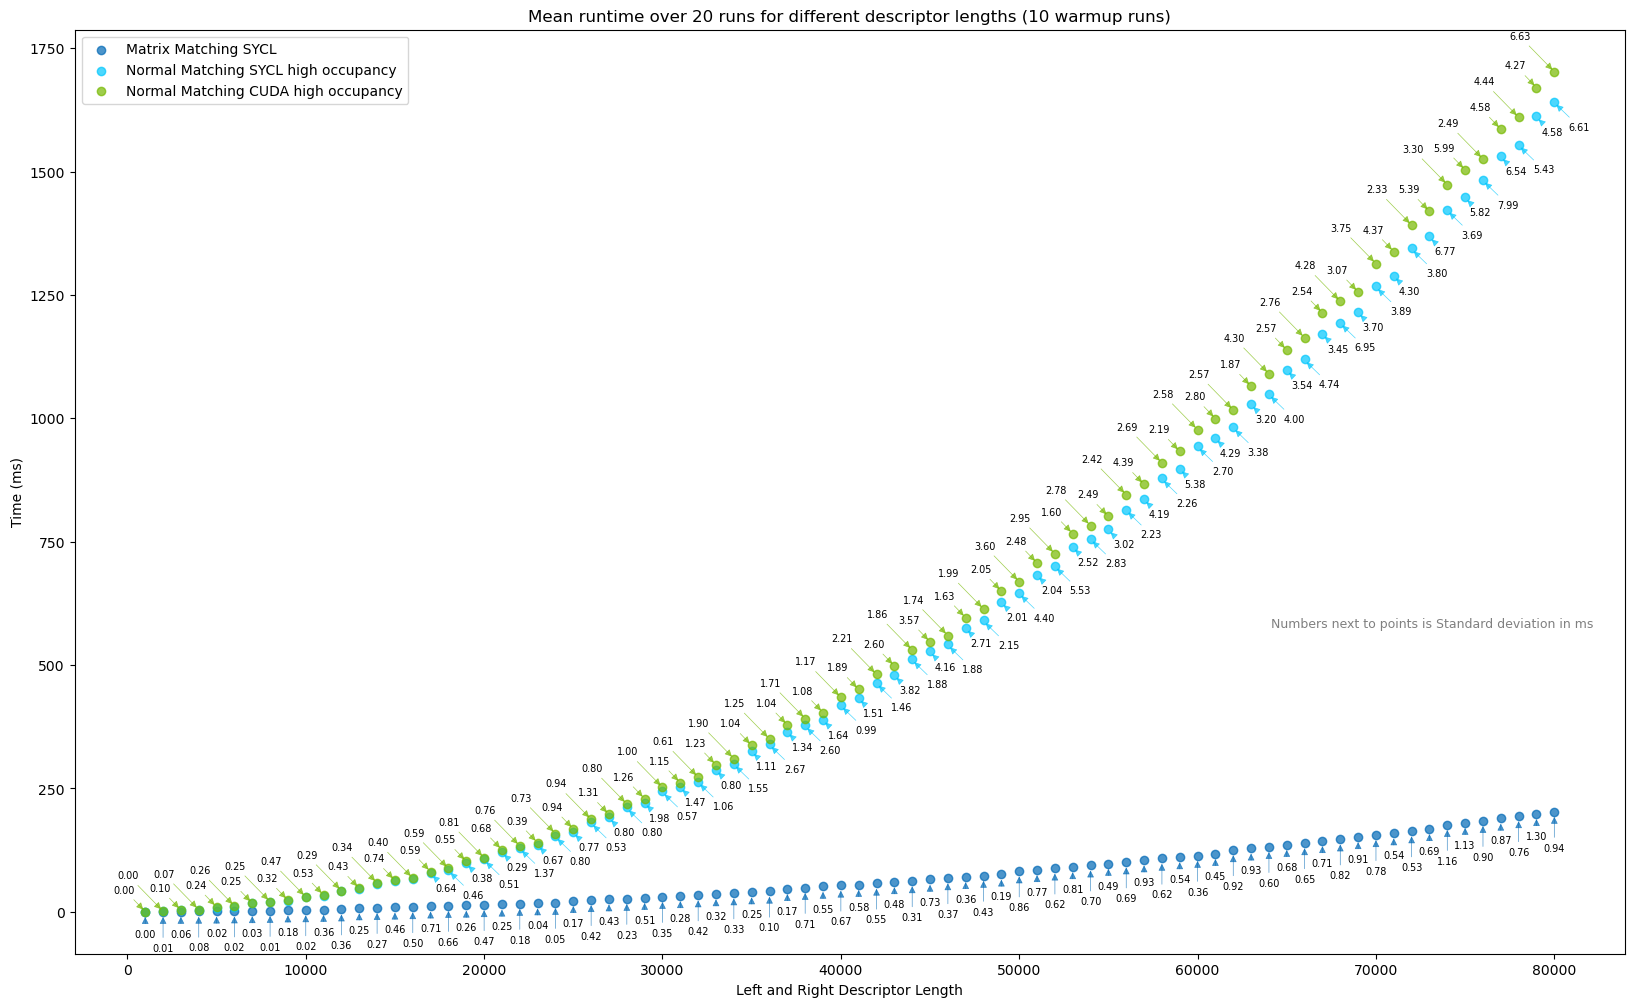

In [45]:
# Scatter plot same data as  above with std annotated for each point 
# plt.figure(figsize=(12, 8))
plt.figure(figsize=(20, 12))
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark, alpha=0.7)
plt.scatter(x_scatter, mean_normal_lr_same_big_wg, label='Normal Matching SYCL high occupancy', color=intel_color, alpha=0.7)
plt.scatter(x_scatter, mean_cuda_normal_lr_same_big_wg, label='Normal Matching CUDA high occupancy', color=nvidia_color, alpha=0.7)


plt.text(0.98, 0.35,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')

offsets = [(0, -15), (0, -25)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_zero, std_matrix_lr_zero), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 5), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color_dark, lw=0.5, alpha=0.7)
    )

# offsets_cuda = [(-15, 10), (-30, 18)]
offsets_cuda = [(-15, 15), (-25, 25)]
offsets_cuda = (offsets_cuda * ((len(x_scatter) // len(offsets_cuda)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_cuda_normal_lr_same_big_wg, std_cuda_normal_lr_same_big_wg), offsets_cuda):
    if xi > 17000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy-3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )
    else:
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi), 
            textcoords="offset points", 
            xytext=(dx,dy-3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=nvidia_color, lw=0.5, alpha=0.7)
        )

# offsets_sycl = [(15, -10), (30, -20)]
offsets_sycl = [(11, -11), (18, -18)]
offsets_sycl = (offsets_sycl * ((len(x_scatter) // len(offsets_sycl)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_normal_lr_same_big_wg, std_normal_lr_same_big_wg), offsets_sycl):
    if xi > 16000:
        plt.annotate(
            f'{stdi:.2f}',
            (xi+2, yi-2), 
            textcoords="offset points", 
            xytext=(dx,dy-3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color, lw=0.5, alpha=0.7)
        )

plt.xlabel('Left and Right Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

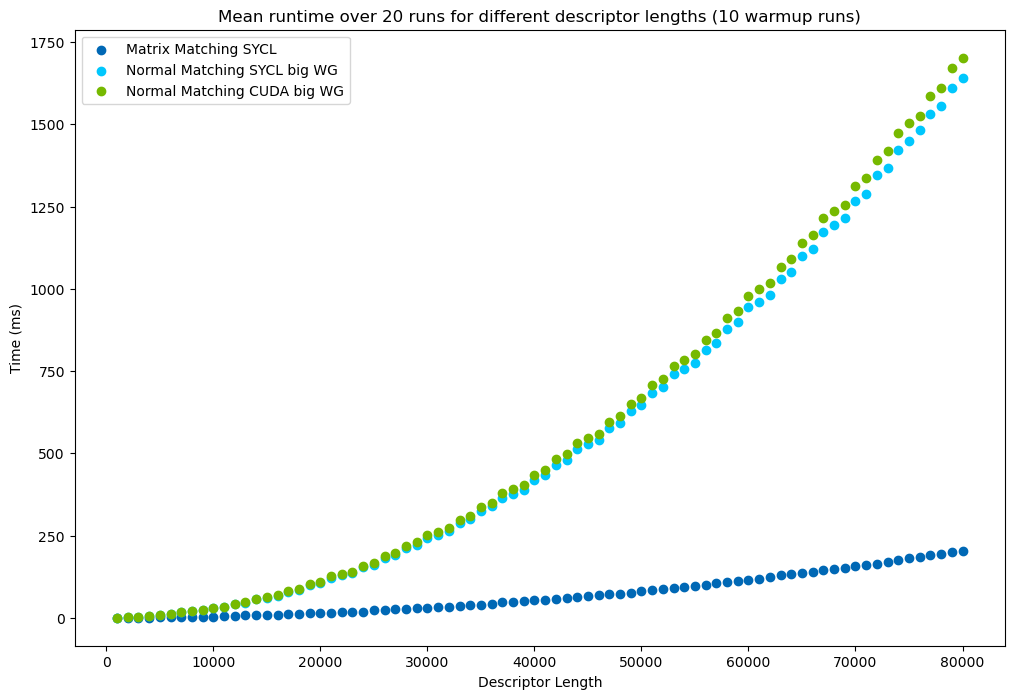

In [46]:
plt.figure(figsize=(12, 8))
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark)
plt.scatter(x_scatter, mean_normal_lr_same_big_wg, label='Normal Matching SYCL big WG', color=intel_color)
plt.scatter(x_scatter, mean_cuda_normal_lr_same_big_wg, label='Normal Matching CUDA big WG', color=nvidia_color)
plt.xlabel('Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()

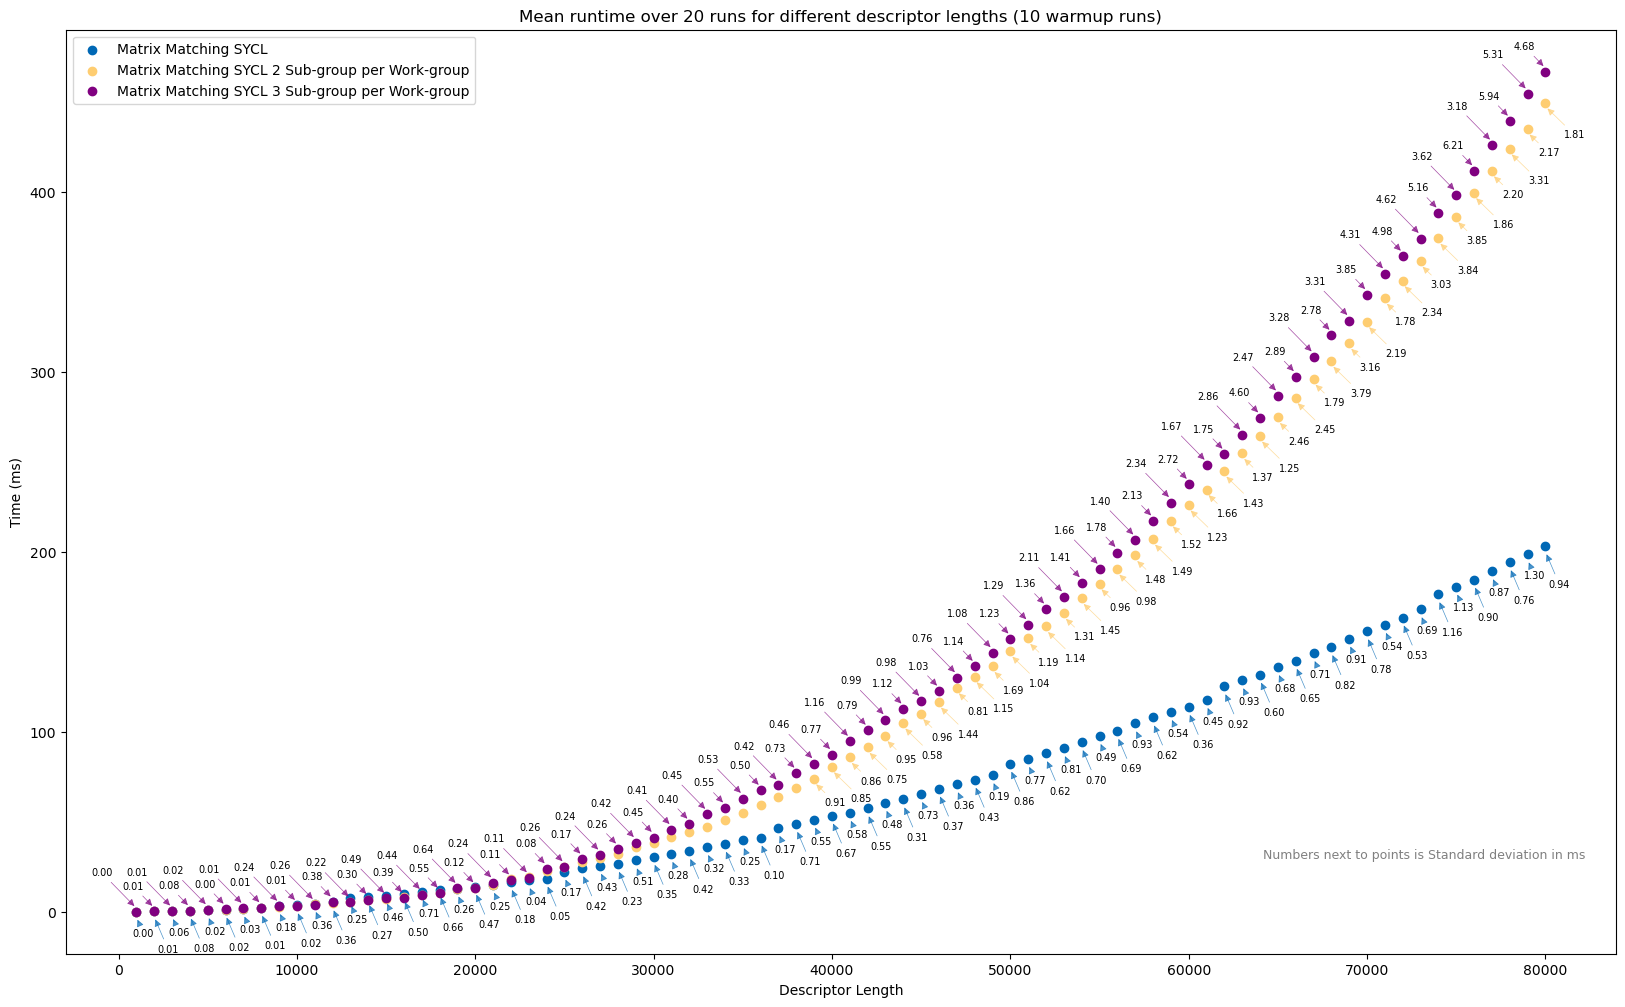

In [74]:

plt.figure(figsize=(20, 12))
plt.scatter(x_scatter, mean_matrix_lr_zero, label='Matrix Matching SYCL', color=intel_color_dark)
plt.scatter(x_scatter, mean_matrix_lr_2_wg, label='Matrix Matching SYCL 2 Sub-group per Work-group', color='#fecd71')
plt.scatter(x_scatter, mean_matrix_lr_3_wg, label='Matrix Matching SYCL 3 Sub-group per Work-group', color='purple')

# Add annotation for the different points
offsets = [(-25, 25), (-15, 15)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]

for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_3_wg, std_matrix_lr_3_wg), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi-1, yi+2), 
        textcoords="offset points", 
        xytext=(dx,dy - 3),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color='purple', lw=0.5, alpha=0.7)
    )

offsets = [(15, -15), (21, -21)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]
for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_2_wg, std_matrix_lr_2_wg), offsets):
    if (xi > 38000):
        plt.annotate(
            f'{stdi:.2f}',
            (xi, yi - 2), 
            textcoords="offset points", 
            xytext=(dx,dy - 3),
            ha='center', 
            va='bottom',
            fontsize=7,
            arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color='#fecd71', lw=0.5, alpha=0.7)
        )

offsets = [(5, -15), (10, -27)]
offsets = (offsets * ((len(x_scatter) // len(offsets)) + 1))[:len(x_scatter)]
for (xi, yi, stdi), (dx, dy) in zip(zip(x_scatter, mean_matrix_lr_zero, std_matrix_lr_zero), offsets):
    plt.annotate(
        f'{stdi:.2f}',
        (xi, yi - 3), 
        textcoords="offset points", 
        xytext=(dx,dy),
        ha='center', 
        va='bottom',
        fontsize=7,
        arrowprops=dict(arrowstyle='-|>,head_length=0.6,head_width=0.3', color=intel_color_dark, lw=0.5, alpha=0.7)
    )


plt.text(0.98, 0.10,
         'Numbers next to points is Standard deviation in ms',
         transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=9, color='gray')


plt.xlabel('Descriptor Length')
plt.ylabel('Time (ms)')
plt.title('Mean runtime over 20 runs for different descriptor lengths (10 warmup runs)')
plt.legend()
plt.show()